Total laps with pit stops:
11667
Total laps
190995
Percentage of laps with pit stops:
6.108536872693002
Average lap time increase compared to previous lap:
8.948819839543395
Average lap time increase compared if leader did not pit:
11.542726836376104
Average lap time increase compared to leader:
15.639589600190385
Under the average lap time increase compared to leader:
4429
Unedr the average lap time increase compared to leader percentage:
52.70109471680152


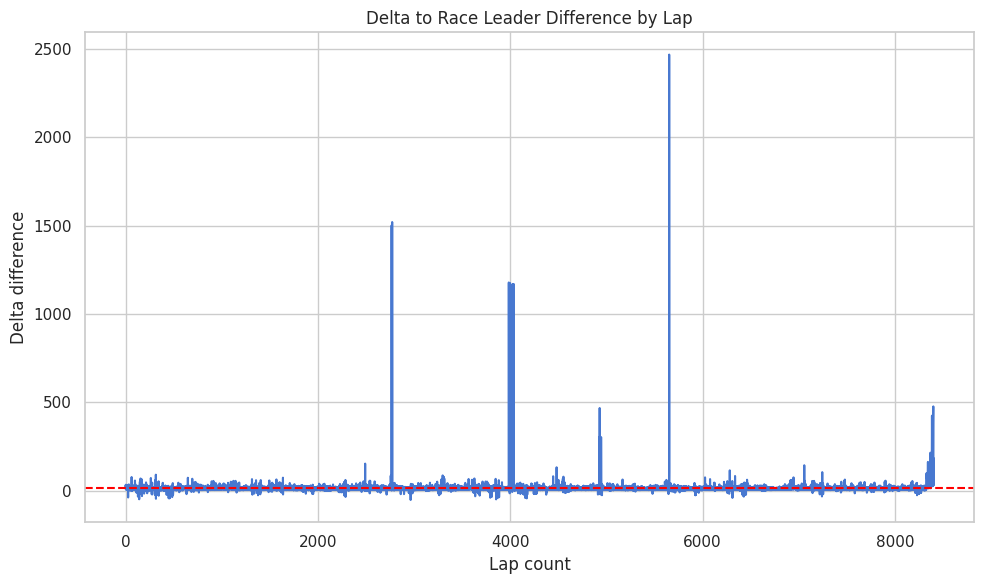

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./export/f1_model_dataset.csv')
df["lap_id"] = df["year"].astype(str) + "_" + df["round_number"].astype(str) + "_" + df["number"].astype(str)

laps_outliers = df[df["pit_lap"] > 0]


print("Total laps with pit stops:")
print(laps_outliers["pit_lap"].count())

print("Total laps")
print(df["pit_lap"].count())

print("Percentage of laps with pit stops:")
print((laps_outliers["pit_lap"].count() / df["pit_lap"].count()) * 100)

print('Average lap time increase compared to previous lap:')
print(laps_outliers["delta_race_leader"].mean() - df["delta_race_leader"].mean())

print('Average lap time increase compared if leader did not pit:')
print(laps_outliers["delta_race_leader"].mean() - df[(df["pit_lap"] == 0) & (df["delta_race_leader"] == 0)]["delta_race_leader"].mean())


merged = laps_outliers.merge(
    df[(df["pit_lap"] == 0) & (df["gap_from_leader"] == 0)],
    on = "lap_id",
    suffixes = ("_outlier", "_leader")
)



difference = merged["delta_race_leader_outlier"] - merged["delta_race_leader_leader"]
mean_difference = difference.mean()

print('Average lap time increase compared to leader:')
print(mean_difference)
print('Under the average lap time increase compared to leader:')
print(difference[difference < mean_difference].count())
print('Unedr the average lap time increase compared to leader percentage:')
print((difference[difference < mean_difference].count() / difference.count()) * 100)

plt.figure(figsize = (10, 6))
plt.plot(range(len(difference)), difference)
plt.axhline(mean_difference, color = 'red', linestyle = '--', label = 'Average Delta Increase')
plt.xlabel("Lap count")
plt.ylabel("Delta difference")
plt.title("Delta to Race Leader Difference by Lap")
plt.tight_layout()
plt.show()

2025 ordering from CSV: ['Mercedes', 'Ferrari', 'Haas F1 Team', 'Red Bull Racing', 'McLaren', 'Racing Bulls', 'Alpine', 'Audi', 'Williams', 'Cadillac', 'Aston Martin']


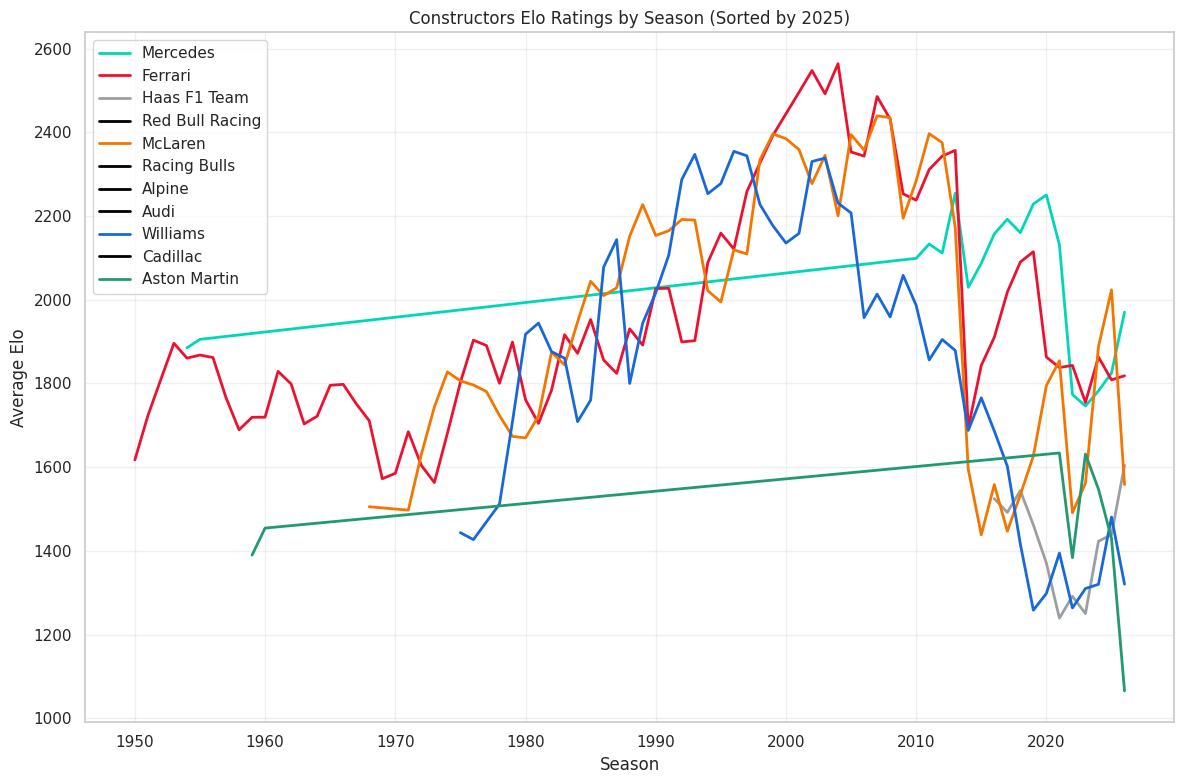

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

const_elo = pd.read_csv("./export/export_constructor_elo.csv")
engine_elo = pd.read_csv("./export/export_engine_elo.csv")


const_elo["constructor"] = const_elo["constructor"].str.strip()


team_season_avg = (
    const_elo
    .groupby(["season", "constructor"])
    ["rating_mu"]
    .mean()
    .reset_index()
)


last_season = team_season_avg["season"].max()

order_2025 = (
    team_season_avg[team_season_avg["season"] == last_season]
    .sort_values("rating_mu", ascending = False)["constructor"]
    .tolist()
)

print("2025 ordering from CSV:", order_2025)

# Pretty colors for teams
team_colors = {
    "McLaren": "#F47600",
    "Mercedes": "#00D7B6",
    "Red Bull": "#4781D7",
    "Ferrari": "#ED1131",
    "Williams": "#1868DB",
    "RB F1 Team": "#6C98FF",
    "Aston Martin": "#229971",
    "Haas F1 Team": "#9C9FA2",
    "Sauber": "#01C00E",
    "Alpine F1 Team": "#00A1E8",
}

plt.figure(figsize = (12, 8))

for team in order_2025:
    data = team_season_avg[team_season_avg["constructor"] == team]
    if data.empty:
        continue

    plt.plot(
        data["season"],
        data["rating_mu"],
        label = team,
        color = team_colors.get(team, "#000000"),
        linewidth = 2
    )

min_year = team_season_avg["season"].min()
max_year = team_season_avg["season"].max()

# build tick labels every 10 years
ticks = list(range(
    (min_year // 10) * 10,
    ((max_year // 10) + 1) * 10,
    10
))

plt.title("Constructors Elo Ratings by Season (Sorted by 2025)")
plt.xlabel("Season")
plt.ylabel("Average Elo")
plt.xticks(ticks)
plt.grid(alpha = 0.3)
plt.legend(loc = "best")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize = (12, 8))

# Standardize engine strings
engine_elo["engine"] = engine_elo["engine"].str.strip()

# Compute average engine Elo per season
engine_season_avg = (
    engine_elo
    .groupby(["season", "engine"])["rating_mu"]
    .mean()
    .reset_index()
)

# Identify all distinct engine makes in 2025
engines_2025 = engine_elo[engine_elo["season"] == 2026]["engine"].unique().tolist()

print("2025 Engines in Data:", engines_2025)

engine_colors = {
    "Mercedes": "#00D7B6",
    "Ferrari":  "#ED1131",
    "Honda RBPT": "#E4002B",
    "Renault":  "#FFD700",
}

for eng in engines_2025:
    eng_data = engine_season_avg[engine_season_avg["engine"] == eng]

    if eng_data.empty:
        continue

    plt.plot(
        eng_data["season"],
        eng_data["rating_mu"],
        label = eng,
        color = engine_colors.get(eng, "#000000"),
        linestyle = "--",
        linewidth = 2
    )

min_year = engine_season_avg["season"].min()
max_year = engine_season_avg["season"].max()

ticks = list(range(
    (min_year // 10) * 10,
    ((max_year // 10) + 1) * 10,
    10
))

plt.title("Engine Elo Ratings by Season (All Engines Present in 2025)")
plt.xlabel("Season")
plt.ylabel("Average Elo")
plt.xticks(ticks)
plt.grid(alpha = 0.25)
plt.legend(loc = "best")
plt.tight_layout()
plt.show()


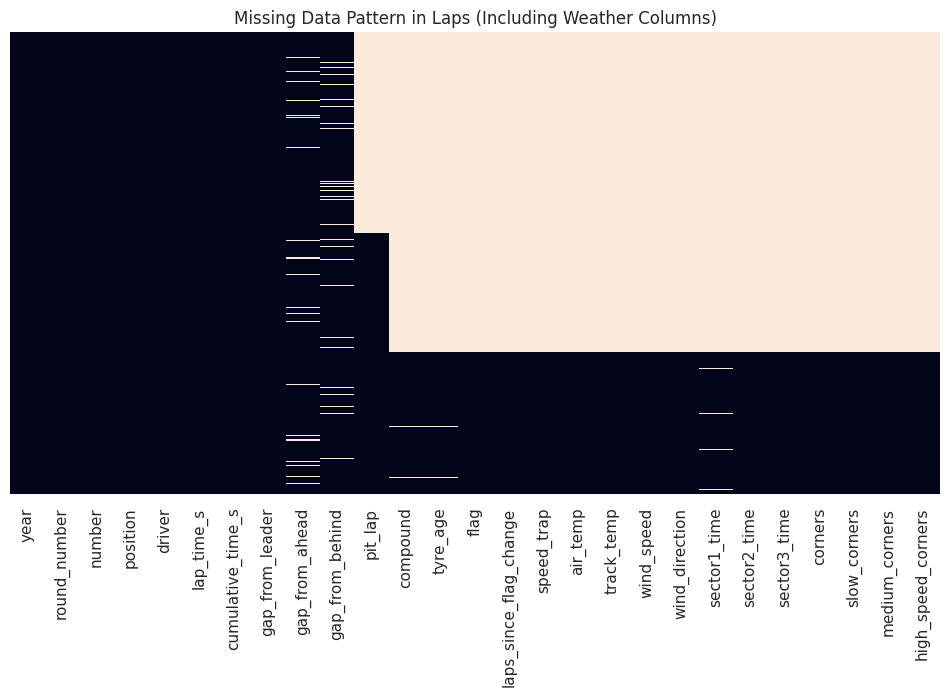

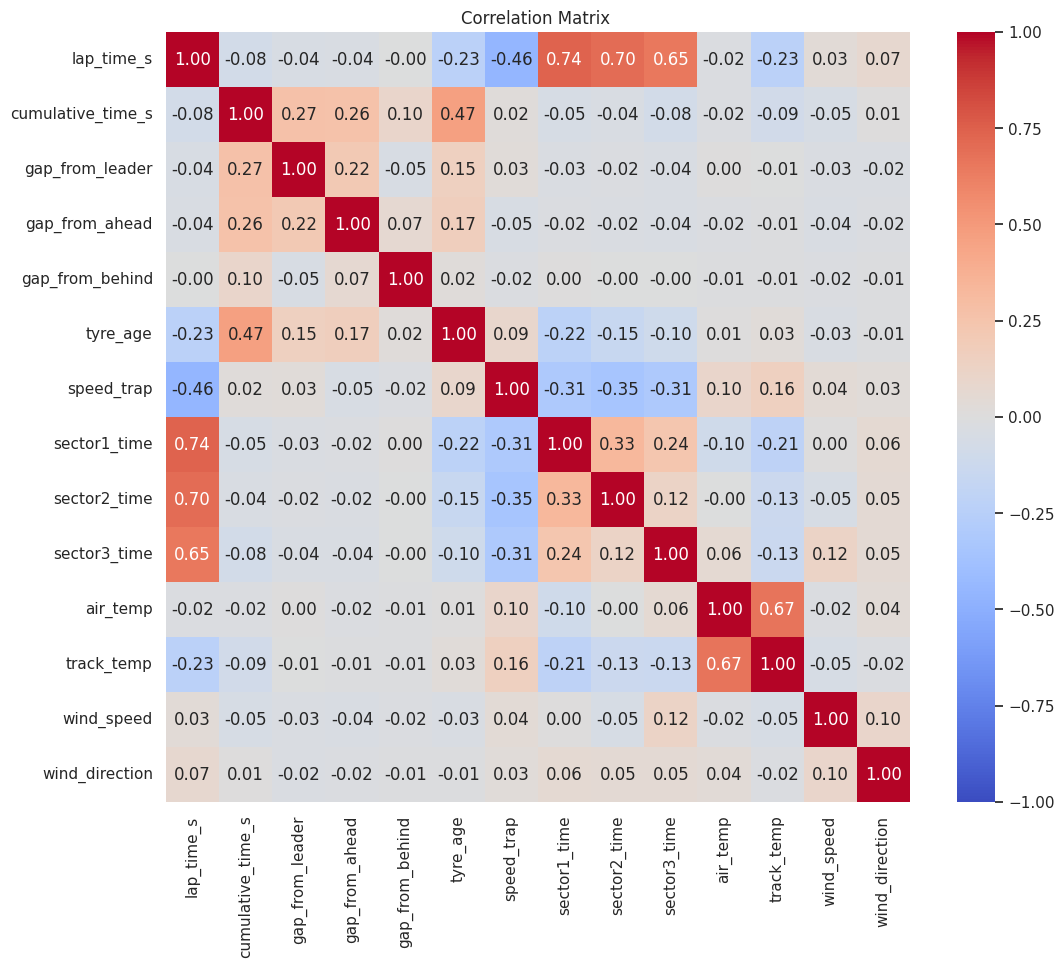

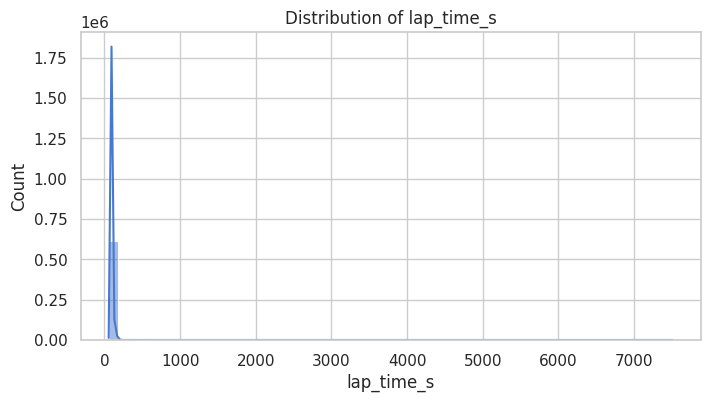

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./export/export_laps.csv", low_memory = False)

df = df.sort_values("year")

plt.figure(figsize = (12, 6))
sns.heatmap(df.isna(), cbar = False, yticklabels = False)
plt.title("Missing Data Pattern in Laps (Including Weather Columns)")
plt.show()


# Define numeric columns
numeric_cols = [
    "lap_time_s", "cumulative_time_s",
    "gap_from_leader", "gap_from_ahead",
    "gap_from_behind", "tyre_age",  
    "speed_trap", "sector1_time",
    "sector2_time", "sector3_time",
    "air_temp", "track_temp", "wind_speed", "wind_direction",
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

df_complete = df[numeric_cols].dropna()

corr = df_complete.corr()

plt.figure(figsize = (12, 10))
sns.heatmap(
    corr,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    vmin = -1,
    vmax = 1
)
plt.title("Correlation Matrix ")
plt.show()



for col in ["lap_time_s", "AirTemp", "TrackTemp", "WindSpeed"]:
    if col in df.columns:
        plt.figure(figsize = (8, 4))
        sns.histplot(df[col].dropna(), bins = 60, kde = True)
        plt.title(f"Distribution of {col}")
        plt.show()


### Dataset Overview

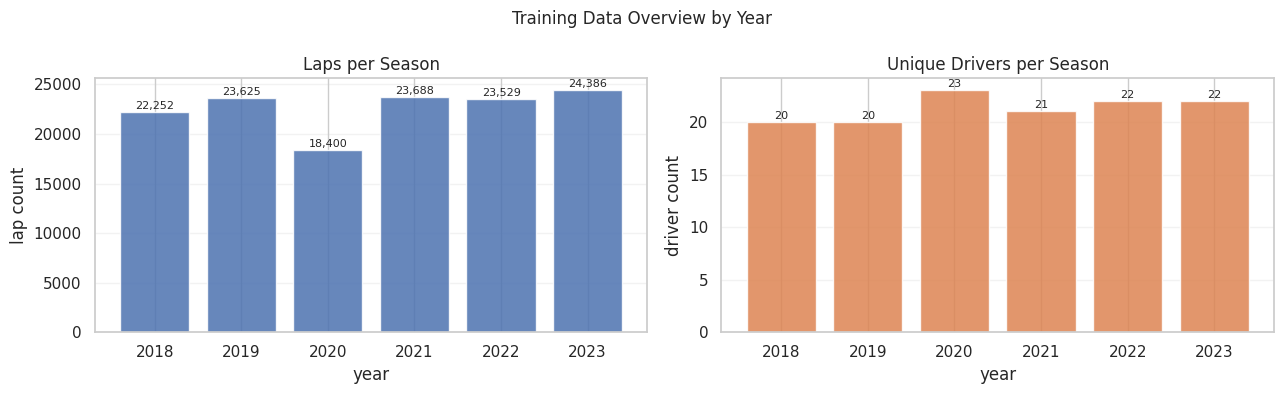

In [ ]:

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("./export/f1_model_dataset.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training Data Overview by Year", fontsize=12)
TRAIN_YEARS = list(range(2018, 2024))
VAL_YEARS = [2024]

df_train = df[df["year"].isin(TRAIN_YEARS)].copy()
df_val = df[df["year"].isin(VAL_YEARS)].copy()


year_laps = df_train.groupby("year").size()
axes[0].bar(year_laps.index, year_laps.values, color="#4c72b0", alpha=0.85, edgecolor="white")
for x, v in zip(year_laps.index, year_laps.values):
    axes[0].text(x, v + 100, f"{v:,}", ha="center", va="bottom", fontsize=8)
axes[0].set_title("Laps per Season")
axes[0].set_xlabel("year")
axes[0].set_ylabel("lap count")
axes[0].grid(True, axis="y", alpha=0.25)

year_drivers = df_train.groupby("year")["driver"].nunique()
axes[1].bar(year_drivers.index, year_drivers.values, color="#dd8452", alpha=0.85, edgecolor="white")
for x, v in zip(year_drivers.index, year_drivers.values):
    axes[1].text(x, v + 0.1, str(v), ha="center", va="bottom", fontsize=8)
axes[1].set_title("Unique Drivers per Season")
axes[1].set_xlabel("year")
axes[1].set_ylabel("driver count")
axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Pit Stops

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Pit Stop Analysis — Training Data", fontsize=12)

# 1. Pit lap fraction per year
pit_frac = df_train.groupby("year").apply(lambda g: (g["pit_lap"] > 0).mean())
axes[0][0].bar(pit_frac.index, pit_frac.values * 100, color="#dd8452", alpha=0.85, edgecolor="white")
for x, v in zip(pit_frac.index, pit_frac.values * 100):
    axes[0][0].text(x, v + 0.05, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
axes[0][0].set_title("Pit Stop Lap Fraction per Year")
axes[0][0].set_xlabel("year")
axes[0][0].set_ylabel("% laps with pit stop")
axes[0][0].grid(True, axis="y", alpha=0.25)

# 2. delta_fastest: pit vs no-pit
pit_vals = df_train.loc[df_train["pit_lap"] > 0, "delta_fastest"].dropna()
nopit_vals = df_train.loc[df_train["pit_lap"] == 0, "delta_fastest"].dropna()

axes[0][1].hist(nopit_vals, bins=80, alpha=0.6, color="#4c72b0", label=f"no pit (n={len(nopit_vals):,})", density=True)
axes[0][1].hist(pit_vals, bins=80, alpha=0.6, color="#c44e52", label=f"pit lap (n={len(pit_vals):,})", density=True)
axes[0][1].axvline(nopit_vals.median(), color="#4c72b0", linestyle="--", linewidth=1.5)
axes[0][1].axvline(pit_vals.median(), color="#c44e52", linestyle="--", linewidth=1.5)
axes[0][1].set_title(
    f"delta_fastest: Pit vs No-Pit\n" +
    f"median no-pit={nopit_vals.median():.2f}s | pit={pit_vals.median():.2f}s"
)
axes[0][1].set_xlabel("delta_fastest (s)")
axes[0][1].set_ylabel("density")
axes[0][1].legend(fontsize=8)
axes[0][1].grid(True, alpha=0.2)

# 3. Distribution of pit stops within a race (by lap number)
pit_laps_in_race = df_train[df_train["pit_lap"] > 0]["number"]
axes[1][0].hist(pit_laps_in_race, bins=60, color="#55a868", alpha=0.85, edgecolor="none")
axes[1][0].set_title("When Do Pit Stops Happen?")
axes[1][0].set_xlabel("lap number")
axes[1][0].set_ylabel("pit stop count")
axes[1][0].grid(True, alpha=0.2)

# 4. Mean delta_fastest by pit_lap value (0, 1, 2 = pit on this lap / in/out)
pit_val_mean = df_train.groupby("pit_lap")["delta_fastest"].mean()
axes[1][1].bar(
    pit_val_mean.index.astype(str),
    pit_val_mean.values,
    color=["#4c72b0", "#c44e52", "#dd8452"][:len(pit_val_mean)],
    alpha=0.85,
    edgecolor="white"
)
for x, v in enumerate(pit_val_mean.values):
    axes[1][1].text(x, v + 0.03, f"{v:.2f}s", ha="center", va="bottom", fontsize=9)
axes[1][1].set_title("Mean delta_fastest by pit_lap Code")
axes[1][1].set_xlabel("pit_lap (0=none, 1=pit-in, 2=pit-out)")
axes[1][1].set_ylabel("mean delta_fastest (s)")
axes[1][1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Flag / Safety Car Analysis

In [ ]:
flag_counts = df_train["flag"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Flag / Safety Car Analysis — Training Data", fontsize=12)

# 1. Flag frequency
flag_colors = {
    "GREEN": "#55a868",
    "YELLOW": "#f0c040",
    "SAFETY_CAR": "#dd8452",
    "VIRTUAL_SAFETY_CAR": "#f0a040",
    "RED": "#c44e52",
}

bar_colors = [flag_colors.get(str(f).upper(), "#777777") for f in flag_counts.index]
axes[0].bar(flag_counts.index.astype(str), flag_counts.values,
            color=bar_colors, alpha=0.9, edgecolor="white")
axes[0].set_title("Lap Count by Flag")
axes[0].set_xlabel("flag")
axes[0].set_ylabel("lap count")
axes[0].tick_params(axis="x", rotation=25)
for i, v in enumerate(flag_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", va="bottom", fontsize=7)
axes[0].grid(True, axis="y", alpha=0.25)

# 2. Mean delta_fastest by flag
flag_delta = df_train.groupby("flag")["delta_fastest"].mean().sort_values()
bar_colors2 = [flag_colors.get(str(f).upper(), "#777777") for f in flag_delta.index]
axes[1].barh(flag_delta.index.astype(str), flag_delta.values,
             color=bar_colors2, alpha=0.9, edgecolor="white")
axes[1].set_title("Mean delta_fastest by Flag")
axes[1].set_xlabel("mean delta_fastest (s)")
axes[1].grid(True, axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


### Tyre Compounds & Tyre Age

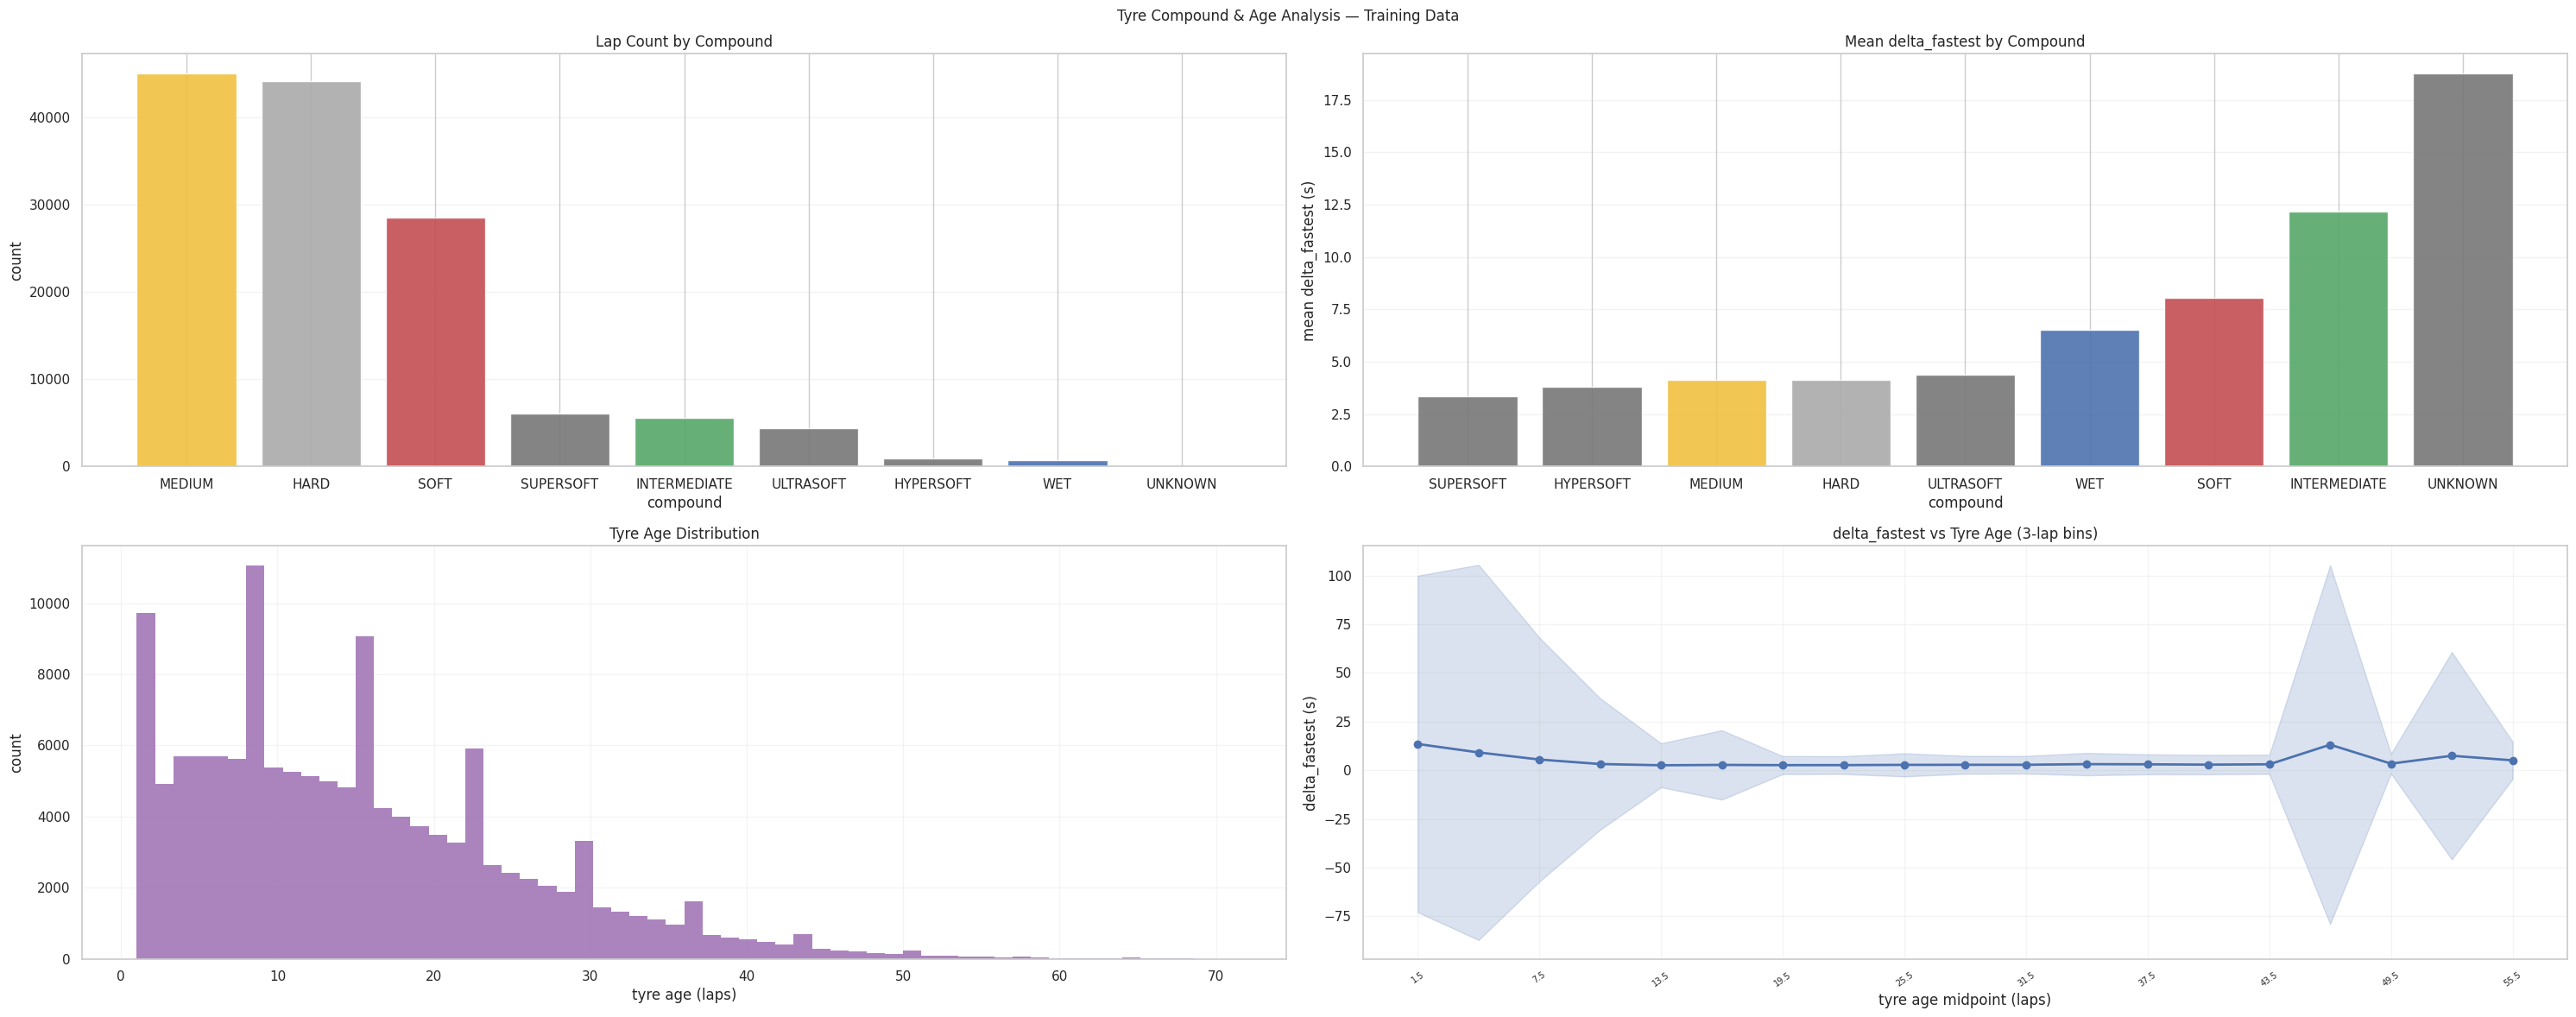

In [ ]:
import numpy as np
compound_colors = {
    "SOFT": "#c44e52",
    "MEDIUM": "#f0c040",
    "HARD": "#aaaaaa",
    "INTERMEDIATE": "#55a868",
    "WET": "#4c72b0",
}

fig, axes = plt.subplots(2, 2, figsize=(30, 12))
fig.suptitle("Tyre Compound & Age Analysis Training Data", fontsize=12)

compounds = df_train["compound"].dropna().unique()

# 1. Compound usage counts
comp_counts = df_train["compound"].value_counts()
bar_colors  = [compound_colors.get(str(c), "#777777") for c in comp_counts.index]
axes[0][0].bar(comp_counts.index.astype(str), comp_counts.values,
               color=bar_colors, alpha=0.9, edgecolor="white")
axes[0][0].set_title("Lap Count by Compound")
axes[0][0].set_xlabel("compound")
axes[0][0].set_ylabel("count")
axes[0][0].grid(True, axis="y", alpha=0.25)

# 3. Mean delta_fastest by compound
comp_delta = df_train.groupby("compound")["delta_fastest"].mean().sort_values()
bar_colors3 = [compound_colors.get(str(c), "#777777") for c in comp_delta.index]
axes[0][1].bar(comp_delta.index.astype(str), comp_delta.values,
               color=bar_colors3, alpha=0.9, edgecolor="white")
axes[0][1].set_title("Mean delta_fastest by Compound")
axes[0][1].set_xlabel("compound")
axes[0][1].set_ylabel("mean delta_fastest")
axes[0][1].grid(True, axis="y", alpha=0.25)

# 4. Tyre age distribution
axes[1][0].hist(df_train["tyre_age"].dropna(), bins=60, color="#9c6fb2", alpha=0.85, edgecolor="none")
axes[1][0].set_title("Tyre Age Distribution")
axes[1][0].set_xlabel("tyre age")
axes[1][0].set_ylabel("count")
axes[1][0].grid(True, alpha=0.2)

# 5. delta_fastest vs tyre age (binned mean + std)
age_bins = pd.cut(df_train["tyre_age"], bins=range(0, 60, 3))
age_grp = df_train.groupby(age_bins, observed=True)["delta_fastest"].agg(["mean", "std"])
x_labels = [str(b.mid) for b in age_grp.index]
x_pos = np.arange(len(age_grp))
axes[1][1].plot(x_pos, age_grp["mean"], "o-", color="#4c72b0", linewidth=2)
axes[1][1].fill_between(x_pos, age_grp["mean"] - age_grp["std"],
                         age_grp["mean"] + age_grp["std"], alpha=0.2, color="#4c72b0")
axes[1][1].set_xticks(x_pos[::2])
axes[1][1].set_xticklabels(x_labels[::2], rotation=35, fontsize=7)
axes[1][1].set_title("delta_fastest vs Tyre Age")
axes[1][1].set_xlabel("tyre age midpoint")
axes[1][1].set_ylabel("delta_fastest")
axes[1][1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Race Position & Gaps

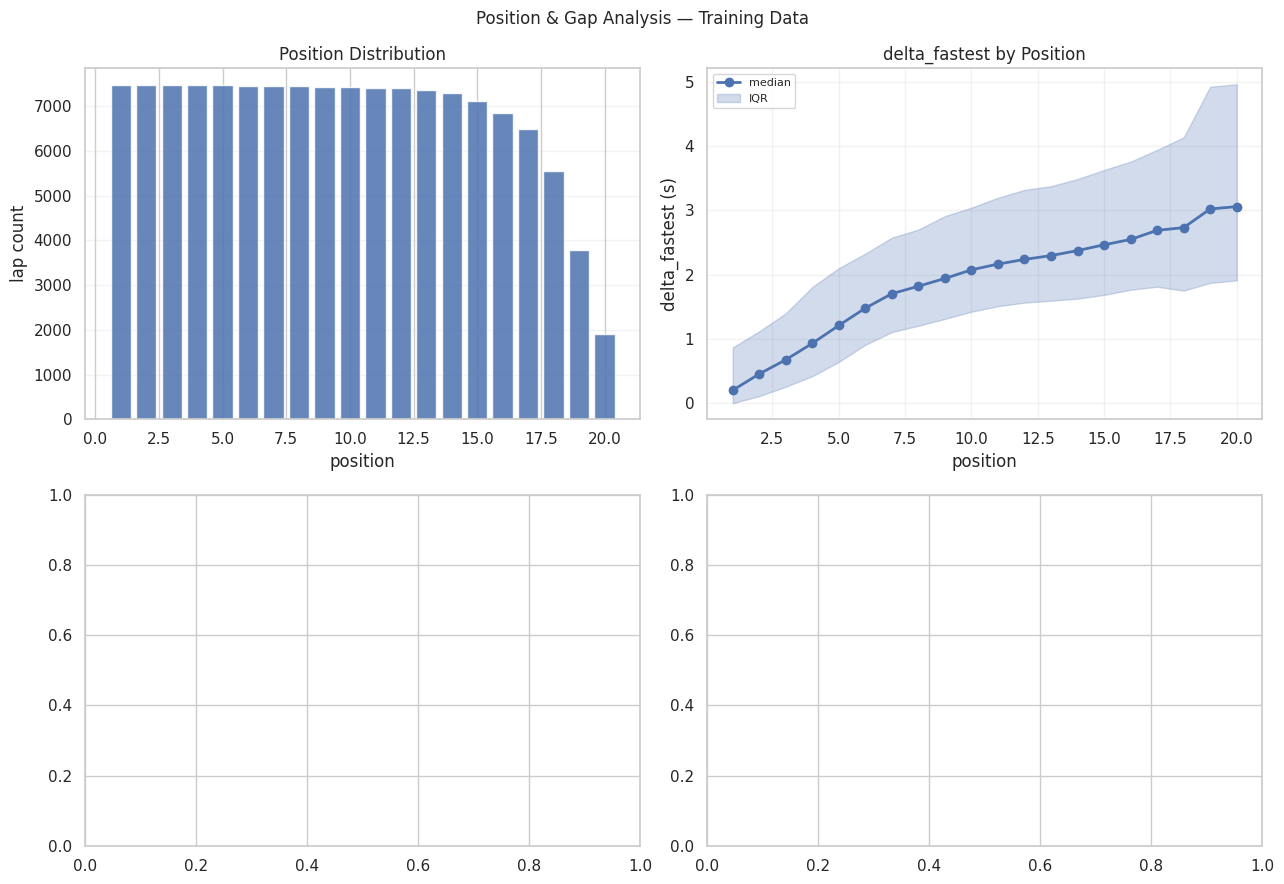

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Position & Gap Analysis Training Data", fontsize=12)

# 1. Position distribution
pos_counts = df_train["position"].value_counts().sort_index()
axes[0][0].bar(pos_counts.index, pos_counts.values, color="#4c72b0", alpha=0.85, edgecolor="white")
axes[0][0].set_title("Position Distribution")
axes[0][0].set_xlabel("position")
axes[0][0].set_ylabel("lap count")
axes[0][0].grid(True, axis="y", alpha=0.25)

# 2. delta_fastest by position (median + IQR)
pos_stats = df_train.groupby("position")["delta_fastest"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).dropna()
axes[0][1].plot(pos_stats.index, pos_stats["median"], "o-", color="#4c72b0", linewidth=2, label="median")
axes[0][1].fill_between(pos_stats.index, pos_stats["q25"], pos_stats["q75"],
                         alpha=0.25, color="#4c72b0", label="IQR")
axes[0][1].set_title("delta_fastest by Position")
axes[0][1].set_xlabel("position")
axes[0][1].set_ylabel("delta_fastest")
axes[0][1].legend(fontsize=8)
axes[0][1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Weather

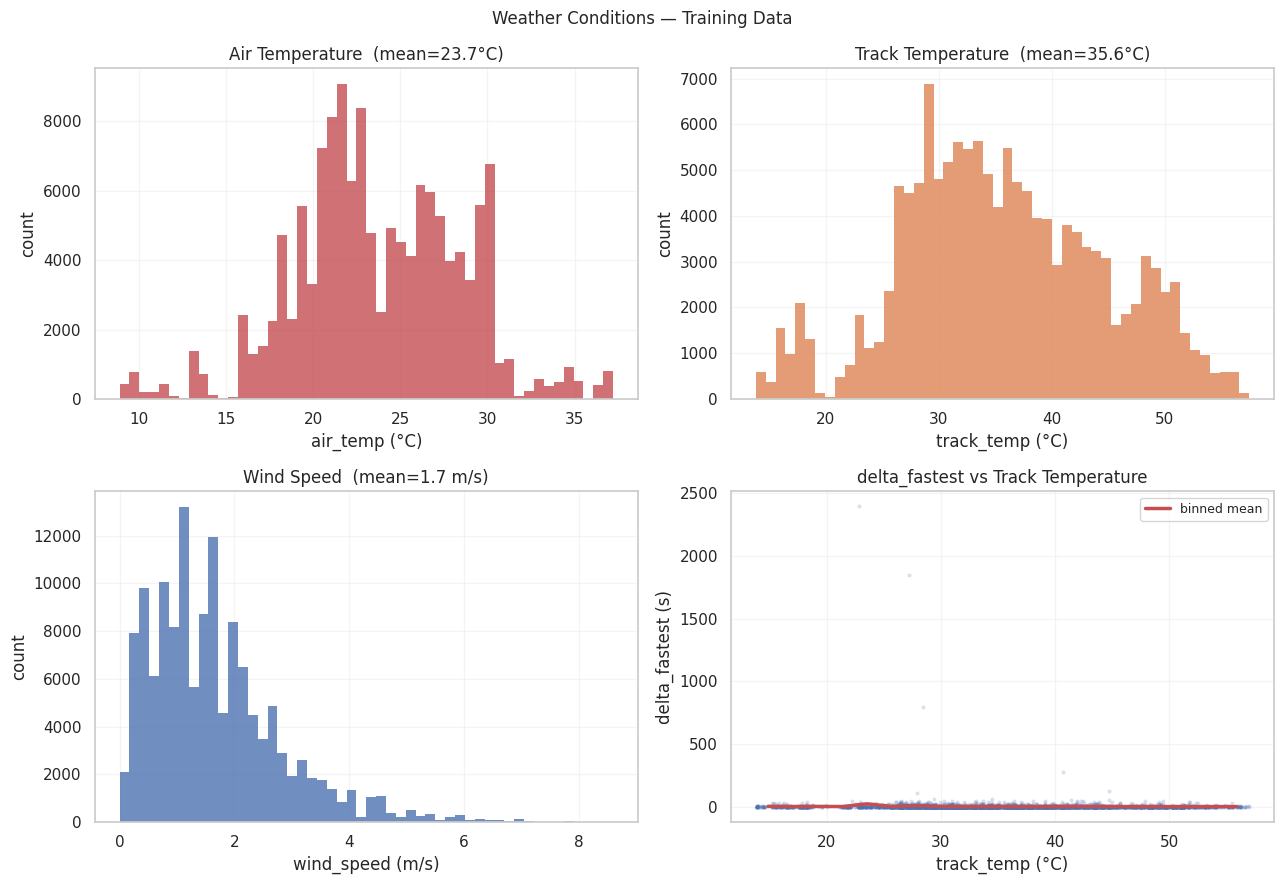

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Weather Conditions Training Data", fontsize=12)

# 1. Air temp distribution
axes[0][0].hist(df_train["air_temp"].dropna(), bins=50, color="#c44e52", alpha=0.8, edgecolor="none")
axes[0][0].set_title(f"Air Temperature (mean={df_train['air_temp'].mean():.1f} C)")
axes[0][0].set_xlabel("air_temp")
axes[0][0].set_ylabel("count")
axes[0][0].grid(True, alpha=0.2)

# 2. Track temp distribution
axes[0][1].hist(df_train["track_temp"].dropna(), bins=50, color="#dd8452", alpha=0.8, edgecolor="none")
axes[0][1].set_title(f"Track Temperature (mean={df_train['track_temp'].mean():.1f} C)")
axes[0][1].set_xlabel("track_temp (C)")
axes[0][1].set_ylabel("count")
axes[0][1].grid(True, alpha=0.2)

# 3. Wind speed distribution
axes[1][0].hist(df_train["wind_speed"].dropna(), bins=50, color="#4c72b0", alpha=0.8, edgecolor="none")
axes[1][0].set_title(f"Wind Speed 1(mean={df_train['wind_speed'].mean():.1f} m/s)")
axes[1][0].set_xlabel("wind_speed (m/s)")
axes[1][0].set_ylabel("count")
axes[1][0].grid(True, alpha=0.2)

# 4. delta_fastest vs track temp (scatter sample + trend line)
sample = df_train[["track_temp", "delta_fastest"]].dropna().sample(min(5000, len(df_train)), random_state=42)
axes[1][1].scatter(sample["track_temp"], sample["delta_fastest"],
                   alpha=0.15, s=4, color="#4c72b0")
# loess-style binned trend
temp_bins = pd.cut(sample["track_temp"], bins=20)
temp_trend = sample.groupby(temp_bins, observed=True)["delta_fastest"].mean()
bin_mids = [b.mid for b in temp_trend.index]
axes[1][1].plot(bin_mids, temp_trend.values, "-", color="#c44e52", linewidth=2.5, label="binned mean")
axes[1][1].set_title("delta_fastest vs Track Temperature")
axes[1][1].set_xlabel("track_temp (C)")
axes[1][1].set_ylabel("delta_fastest")
axes[1][1].legend(fontsize=9)
axes[1][1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Feature Correlations with Target

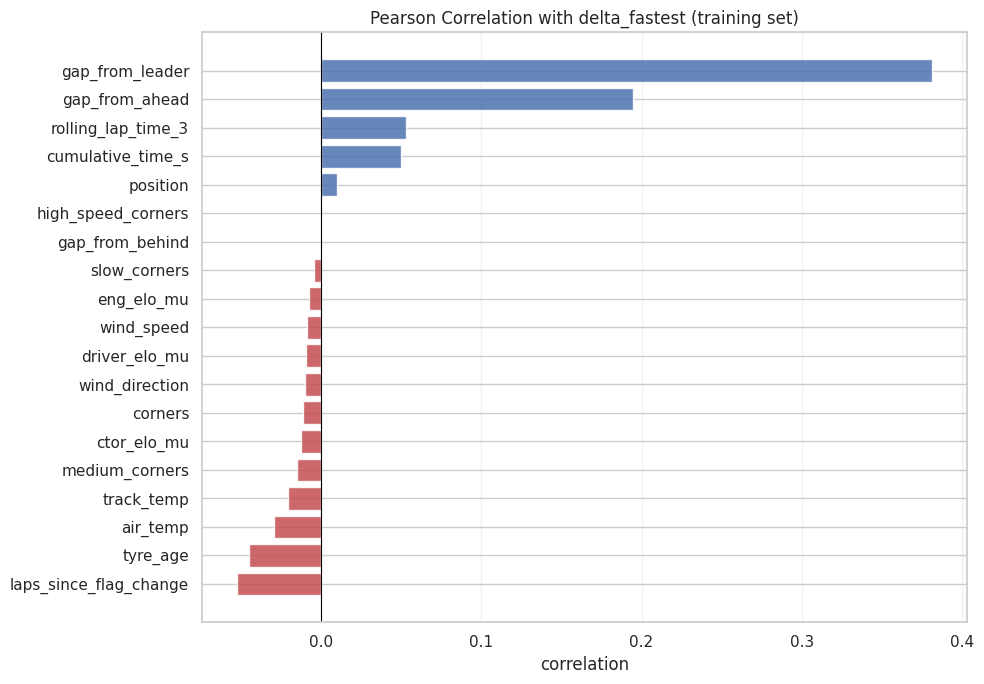

In [25]:
numeric_features = [
    "position", "gap_from_leader", "gap_from_ahead", "gap_from_behind",
    "tyre_age", "rolling_lap_time_3", "laps_since_flag_change",
    "air_temp", "track_temp", "wind_speed", "wind_direction",
    "cumulative_time_s", "ctor_elo_mu", "eng_elo_mu", "driver_elo_mu",
    "corners", "slow_corners", "medium_corners", "high_speed_corners",
]
numeric_features = [c for c in numeric_features if c in df_train.columns]

corrs = (
    df_train[numeric_features + ["delta_fastest"]]
    .corr()["delta_fastest"]
    .drop("delta_fastest")
    .sort_values()
)

colors = ["#c44e52" if v < 0 else "#4c72b0" for v in corrs.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(corrs.index, corrs.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with delta_fastest (training set)", fontsize=12)
ax.set_xlabel("correlation")
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()